In [1]:
import pandas as pd

df = pd.read_csv("fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [2]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

(17880, 18)

In [3]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [4]:
df.drop(columns=['job_id'], inplace=True)

In [5]:
cols_fill = ['salary_range', 'company_profile', 'benefits']

for col in cols_fill:
    df[col] = df[col].fillna("Not Provided")

In [6]:
text_cols = ['description', 'requirements']

for col in text_cols:
    df[col] = df[col].fillna("")

In [7]:
df.dropna(subset=['title', 'location'], inplace=True)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\n', ' ', text)  # remove new lines
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)  # remove special chars
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces
    return text.strip()

In [10]:
df['description'] = df['description'].apply(clean_text)
df['requirements'] = df['requirements'].apply(clean_text)
df['company_profile'] = df['company_profile'].apply(clean_text)

In [12]:
df[['country', 'state', 'city']] = (
    df['location']
      .str.split(',', n=2, expand=True)
)

In [13]:
df['country'] = df['country'].str.strip()
df['state'] = df['state'].str.strip()
df['city'] = df['city'].str.strip()

In [14]:
df[['salary_min', 'salary_max']] = df['salary_range'].str.split('-', expand=True)

In [16]:
df['salary_min'] = pd.to_numeric(df['salary_min'], errors='coerce')
df['salary_max'] = pd.to_numeric(df['salary_max'], errors='coerce')

In [17]:
bool_cols = ['telecommuting', 'has_company_logo', 'has_questions']

for col in bool_cols:
    df[col] = df[col].astype(int)

In [18]:
df['fraudulent'].value_counts()

fraudulent
0    16421
1      837
Name: count, dtype: int64

In [20]:
df.isnull().sum()
df.head()
df.describe()

,telecommuting,has_company_logo,has_questions,fraudulent,salary_min,salary_max
count,17258.000000,17258.000000,17258.000000,17258.000000,2.801000e+03,2.785000e+03
mean,0.042473,0.793197,0.491888,0.048499,5.220962e+05,8.276128e+05
std,0.201672,0.405024,0.499949,0.214825,1.782211e+07,2.732792e+07
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,0.000000,1.000000,0.000000,0.000000,1.800000e+04,2.500000e+04
50%,0.000000,1.000000,0.000000,0.000000,3.500000e+04,5.000000e+04
75%,0.000000,1.000000,1.000000,0.000000,6.000000e+04,9.000000e+04
max,1.000000,1.000000,1.000000,1.000000,8.000000e+08,1.200000e+09


In [21]:
df['salary_missing'] = (df['salary_range'] == "Not Provided").astype(int)

In [22]:
df['company_profile_missing'] = (df['company_profile'] == "Not Provided").astype(int)

In [23]:
df['desc_length'] = df['description'].apply(len)

In [25]:
df['req_length'] = df['requirements'].apply(len)

In [26]:
risk_words = [
    'urgent hiring', 'quick money', 'easy money',
    'no experience', 'work from home', 'limited seats',
    'earn extra', 'immediate joining'
]

In [27]:
def keyword_score(text):
    score = 0
    for word in risk_words:
        if word in text:
            score += 1
    return score

In [28]:
df['keyword_risk'] = df['description'].apply(keyword_score)

In [29]:
df.rename(columns={'has_company_logo': 'logo_present'}, inplace=True)

In [30]:
df.rename(columns={'has_questions': 'questions_present'}, inplace=True)

In [31]:
df.rename(columns={'telecommuting': 'telecommute_flag'}, inplace=True)

In [32]:
df['title_length'] = df['title'].apply(len)

In [33]:
df['desc_word_count'] = df['description'].apply(lambda x: len(x.split()))

In [34]:
df[['salary_missing','company_profile_missing','desc_length',
    'keyword_risk','logo_present','questions_present',
    'telecommute_flag','fraudulent']].head()

,salary_missing,company_profile_missing,desc_length,keyword_risk,logo_present,questions_present,telecommute_flag,fraudulent
0,1,0,881,0,1,0,0,0
1,1,0,2009,0,1,0,0,0
2,1,0,348,0,1,0,0,0
3,1,0,2556,0,1,0,0,0
4,1,0,1396,0,1,1,0,0


In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['desc_length','req_length','title_length','desc_word_count','keyword_risk']] = \
    scaler.fit_transform(df[['desc_length','req_length','title_length','desc_word_count','keyword_risk']])

In [36]:
df['logo_risk'] = 1 - df['logo_present']
df['questions_risk'] = 1 - df['questions_present']

In [37]:
df['ghost_score'] = (
    0.15 * df['salary_missing'] +
    0.15 * df['company_profile_missing'] +
    0.10 * df['keyword_risk'] +
    0.10 * df['logo_risk'] +
    0.10 * df['questions_risk'] +
    0.10 * df['telecommute_flag'] +
    0.10 * (1 - df['desc_length']) +
    0.05 * (1 - df['req_length']) +
    0.05 * (1 - df['title_length']) +
    0.10 * (1 - df['desc_word_count'])
)

In [38]:
df['ghost_score'] = df['ghost_score'] * 100

In [41]:
q1 = df['ghost_score'].quantile(0.33)
q2 = df['ghost_score'].quantile(0.66)

def risk_label(score):
    if score < q1:
        return "Safe"
    elif score < q2:
        return "Suspicious"
    else:
        return "Likely Ghost"

df['risk_label'] = df['ghost_score'].apply(risk_label)

In [42]:
df.groupby('risk_label')['fraudulent'].mean()

risk_label
Likely Ghost    0.079925
Safe            0.027392
Suspicious      0.037226
Name: fraudulent, dtype: float64

<Axes: xlabel='fraudulent', ylabel='ghost_score'>

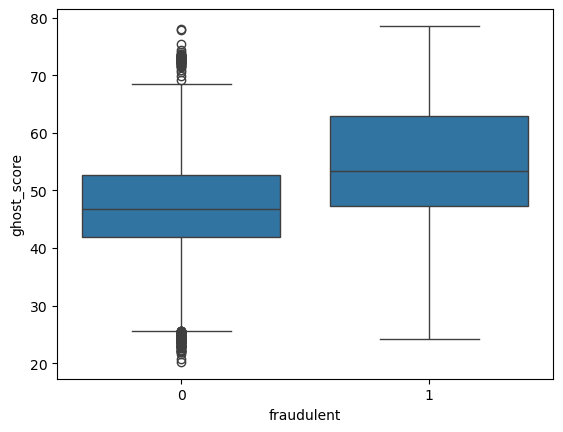

In [43]:
import seaborn as sns
sns.boxplot(x='fraudulent', y='ghost_score', data=df)

In [44]:
#Machine Learning Modelling

In [45]:
features = [
    'salary_missing',
    'company_profile_missing',
    'desc_length',
    'req_length',
    'keyword_risk',
    'logo_risk',
    'questions_risk',
    'telecommute_flag',
    'title_length',
    'desc_word_count'
]

In [46]:
target = 'fraudulent'

In [47]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [50]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3285
           1       0.74      0.08      0.15       167

    accuracy                           0.95      3452
   macro avg       0.85      0.54      0.56      3452
weighted avg       0.94      0.95      0.94      3452

ROC-AUC: 0.7621979784722792


In [51]:
import pandas as pd

comparison = pd.DataFrame({
    'ghost_score': df.loc[X_test.index, 'ghost_score'],
    'ml_probability': y_prob
})

comparison.corr()

,ghost_score,ml_probability
ghost_score,1.000000,0.445095
ml_probability,0.445095,1.000000


In [68]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3285
           1       0.90      0.40      0.55       167

    accuracy                           0.97      3452
   macro avg       0.94      0.70      0.77      3452
weighted avg       0.97      0.97      0.96      3452

ROC-AUC: 0.8799433097275768


In [69]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values(ascending=False)

desc_length                0.252016
desc_word_count            0.218194
req_length                 0.203839
title_length               0.165568
logo_risk                  0.062292
keyword_risk               0.051982
salary_missing             0.019240
questions_risk             0.018882
telecommute_flag           0.007986
company_profile_missing    0.000000
dtype: float64

In [52]:
#EDA

In [53]:
df['fraudulent'].value_counts(normalize=True)

fraudulent
0    0.951501
1    0.048499
Name: proportion, dtype: float64

<Axes: xlabel='fraudulent', ylabel='ghost_score'>

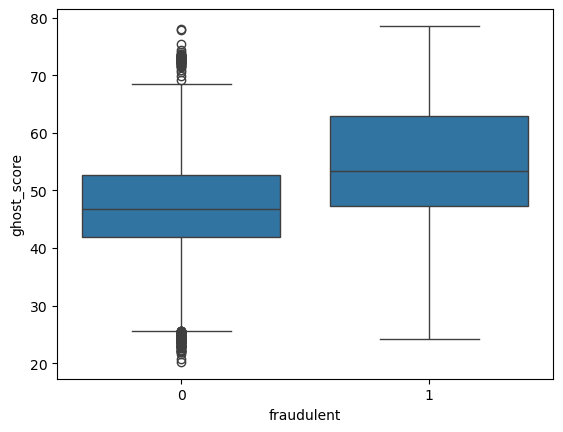

In [54]:
import seaborn as sns
sns.boxplot(x='fraudulent', y='ghost_score', data=df)

In [56]:
df.groupby('risk_label')['fraudulent'].mean()

risk_label
Likely Ghost    0.079925
Safe            0.027392
Suspicious      0.037226
Name: fraudulent, dtype: float64

In [57]:
df.groupby('salary_missing')['fraudulent'].mean()

salary_missing
0    0.078075
1    0.042759
Name: fraudulent, dtype: float64

In [58]:
df.groupby('company_profile_missing')['fraudulent'].mean()

company_profile_missing
0    0.048499
Name: fraudulent, dtype: float64

<Axes: xlabel='desc_length', ylabel='Count'>

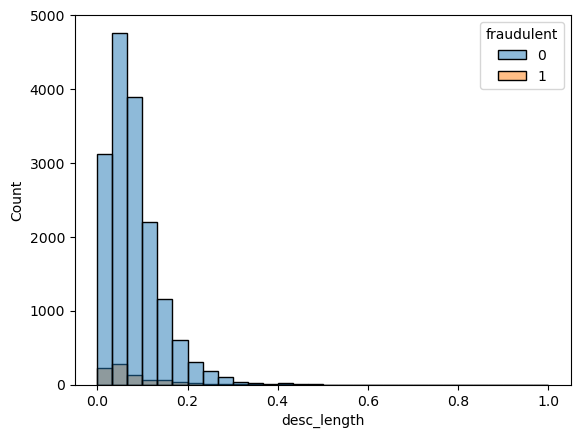

In [59]:
sns.histplot(data=df, x='desc_length', hue='fraudulent', bins=30)

In [60]:
df.groupby('keyword_risk')['fraudulent'].mean()

keyword_risk
0.0    0.043243
0.5    0.427966
1.0    0.000000
Name: fraudulent, dtype: float64

In [61]:
df.groupby('logo_present')['fraudulent'].mean()

logo_present
0    0.156627
1    0.020308
Name: fraudulent, dtype: float64

In [62]:
df.groupby('questions_present')['fraudulent'].mean()

questions_present
0    0.067168
1    0.029214
Name: fraudulent, dtype: float64

In [63]:
df[df['fraudulent']==1]['country'].value_counts().head(10)

country
US    721
AU     39
GB     23
MY     12
CA     12
QA      6
BH      5
IN      4
PL      3
TW      2
Name: count, dtype: int64

In [64]:
df.groupby('industry')['fraudulent'].mean().sort_values(ascending=False).head(10)

industry
Ranching                           1.000000
Military                           0.500000
Animation                          0.400000
Oil & Energy                       0.373239
Accounting                         0.358491
Computer Networking                0.285714
Leisure, Travel & Tourism          0.281690
Executive Office                   0.250000
Defense & Space                    0.222222
Business Supplies and Equipment    0.166667
Name: fraudulent, dtype: float64

In [70]:
importance.sort_values(ascending=False)

desc_length                0.252016
desc_word_count            0.218194
req_length                 0.203839
title_length               0.165568
logo_risk                  0.062292
keyword_risk               0.051982
salary_missing             0.019240
questions_risk             0.018882
telecommute_flag           0.007986
company_profile_missing    0.000000
dtype: float64

In [ ]:
#import to csv

In [71]:
df.to_csv("ghost_job_final.csv", index=False)